# Transformers: Do Zero ao Fine-Tuning

**Machine Learning — Abordagem Prática com Noções Teóricas**

Este notebook acompanha os slides da aula e demonstra, passo a passo, cada componente de um Transformer:

| Secção | Conteúdo |
|--------|----------|
| 1 | Instalação e imports |
| 2 | Tokenização |
| 3 | Embeddings e Positional Encoding |
| 4 | Scaled Dot-Product Attention |
| 5 | Self-Attention |
| 6 | Multi-Head Attention |
| 7 | Bloco Transformer completo |
| 8 | BERT — modelo pré-treinado |
| 9 | GPT — geração de texto |
| 10 | Fine-tuning de BERT para análise de sentimento |

---

## 1. Instalação e Imports

Vamos instalar e importar as bibliotecas necessárias:

| Biblioteca | Descrição |
|------------|-----------|
| `torch` | Framework de deep learning (PyTorch) |
| `transformers` | Biblioteca HuggingFace com modelos pré-treinados (BERT, GPT, etc.) |
| `datasets` | Datasets prontos a usar do HuggingFace |
| `matplotlib` | Visualização de gráficos e heatmaps |
| `numpy` | Operações numéricas |

In [ ]:
# Instalar bibliotecas (descomentar se necessário)
# !pip install torch transformers datasets matplotlib numpy

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# Verificar se há GPU disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"PyTorch versão: {torch.__version__}")

Dispositivo: cpu
PyTorch versão: 2.10.0+cpu


---
## 2. Tokenização

A **tokenização** é o primeiro passo de qualquer pipeline de NLP. Transforma texto em unidades numéricas que o modelo consegue processar.

### 2.1 Tokenização manual — entender o conceito

Antes de usar bibliotecas, vamos ver o processo básico:

```
Texto → Tokens (sub-palavras) → IDs numéricos → Embeddings (vectores)
```

In [4]:
# ============================================================
# Tokenização simples (word-level) — como faziam os LSTMs
# ============================================================

frase = "O gato desapareceu"

# Tokenização word-level: simplesmente dividir por espaços
tokens_word = frase.split()
print(f"Frase: '{frase}'")
print(f"Tokens word-level: {tokens_word}")
print(f"Número de tokens: {len(tokens_word)}")

Frase: 'O gato desapareceu'
Tokens word-level: ['O', 'gato', 'desapareceu']
Número de tokens: 3


### 2.2 Tokenização com HuggingFace (`AutoTokenizer`)

Os Transformers usam tokenização **subword** — dividem palavras desconhecidas em pedaços mais pequenos.

Vamos usar o `AutoTokenizer`, que carrega automaticamente o tokenizer correto para cada modelo.

**Função `AutoTokenizer.from_pretrained(model_name)`:**

| Parâmetro | Tipo | Descrição |
|-----------|------|-----------|
| `model_name` | `str` | Nome do modelo no HuggingFace Hub (ex: `"bert-base-uncased"`) |

In [5]:
from transformers import AutoTokenizer

# Carregar o tokenizer do BERT
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")

frase = "O gato desapareceu"

# tokenize() — converte texto em lista de sub-palavras (strings)
tokens = tokenizer_bert.tokenize(frase)
print(f"Frase: '{frase}'")
print(f"Tokens subword (BERT): {tokens}")
print(f"Número de tokens: {len(tokens)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

c:\Source\Repos\obimelo\Curso-MachineLearning-FCUP\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jamelo\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Frase: 'O gato desapareceu'
Tokens subword (BERT): ['o', 'ga', '##to', 'des', '##apa', '##re', '##ce', '##u']
Número de tokens: 8


### 2.3 Do texto aos IDs e de volta

O tokenizer converte texto em IDs numéricos (posição no vocabulário) e vice-versa.

**Método `tokenizer(text, ...)`** — a forma mais completa de tokenizar:

| Parâmetro | Tipo | Descrição |
|-----------|------|-----------|
| `text` | `str` | Texto de entrada |
| `return_tensors` | `str` | Formato de saída: `"pt"` (PyTorch), `"tf"` (TensorFlow), `"np"` (NumPy) |
| `padding` | `bool/str` | Adicionar padding para igualar comprimentos. `True` = pad ao maior da batch |
| `truncation` | `bool` | Cortar sequências que excedam `max_length` |
| `max_length` | `int` | Comprimento máximo da sequência (BERT: máx 512) |
| `add_special_tokens` | `bool` | Adicionar `[CLS]` e `[SEP]` automaticamente (default: `True`) |

In [6]:
# Tokenização completa: texto → IDs
frase = "O gato desapareceu"

encoded = tokenizer_bert(
    frase,
    return_tensors="pt",     # devolver tensores PyTorch
    padding=True,             # adicionar padding se necessário
    truncation=True,          # cortar se exceder max_length
    max_length=128            # comprimento máximo
)

print("Chaves do output:", list(encoded.keys()))
print(f"\nInput IDs: {encoded['input_ids']}")
print(f"Attention mask: {encoded['attention_mask']}")

# Descodificar de volta: IDs → texto
decoded = tokenizer_bert.decode(encoded['input_ids'][0])
print(f"\nDescodificado: '{decoded}'")

# Ver cada token e o seu ID
tokens = tokenizer_bert.convert_ids_to_tokens(encoded['input_ids'][0])
ids = encoded['input_ids'][0].tolist()
print("\nToken → ID:")
for tok, id_ in zip(tokens, ids):
    print(f"  {tok:15s} → {id_}")

Chaves do output: ['input_ids', 'token_type_ids', 'attention_mask']

Input IDs: tensor([[  101,  1051, 11721,  3406,  4078, 22068,  2890,  3401,  2226,   102]])
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Descodificado: '[CLS] o gato desapareceu [SEP]'

Token → ID:
  [CLS]           → 101
  o               → 1051
  ga              → 11721
  ##to            → 3406
  des             → 4078
  ##apa           → 22068
  ##re            → 2890
  ##ce            → 3401
  ##u             → 2226
  [SEP]           → 102


### 2.4 Comparar tokenizers de modelos diferentes

Cada modelo usa o seu próprio vocabulário e algoritmo de tokenização:
- **BERT**: WordPiece (prefixo `##` para continuações)
- **GPT-2**: BPE — Byte Pair Encoding (prefixo `Ġ` para espaço antes da palavra)
- **BERT português**: WordPiece treinado em corpora em português

In [7]:
# Comparar tokenizers
tokenizer_gpt = AutoTokenizer.from_pretrained("gpt2")
tokenizer_pt  = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

frase = "O gato desapareceu misteriosamente"

print(f"Frase: '{frase}'\n")
print(f"BERT (en):    {tokenizer_bert.tokenize(frase)}")
print(f"GPT-2 (en):   {tokenizer_gpt.tokenize(frase)}")
print(f"BERT (pt):    {tokenizer_pt.tokenize(frase)}")

print(f"\nVocabulário BERT (en): {tokenizer_bert.vocab_size} tokens")
print(f"Vocabulário GPT-2:     {tokenizer_gpt.vocab_size} tokens")
print(f"Vocabulário BERT (pt): {tokenizer_pt.vocab_size} tokens")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\Source\Repos\obimelo\Curso-MachineLearning-FCUP\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jamelo\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Frase: 'O gato desapareceu misteriosamente'

BERT (en):    ['o', 'ga', '##to', 'des', '##apa', '##re', '##ce', '##u', 'mister', '##ios', '##ament', '##e']
GPT-2 (en):   ['O', 'Ġg', 'ato', 'Ġdes', 'ap', 'are', 'ce', 'u', 'Ġm', 'ister', 'ios', 'ament', 'e']
BERT (pt):    ['O', 'gato', 'desapareceu', 'misteriosa', '##mente']

Vocabulário BERT (en): 30522 tokens
Vocabulário GPT-2:     50257 tokens
Vocabulário BERT (pt): 29794 tokens


---
## 3. Embeddings e Positional Encoding

Depois da tokenização, cada ID é convertido num **vector denso** (embedding).

### 3.1 Embedding Layer

**`torch.nn.Embedding(num_embeddings, embedding_dim)`:**

| Parâmetro | Tipo | Descrição |
|-----------|------|-----------|
| `num_embeddings` | `int` | Tamanho do vocabulário (quantas palavras diferentes) |
| `embedding_dim` | `int` | Dimensão de cada vector (BERT: 768, GPT-2: 768) |

Funciona como uma **tabela de consulta**: dado um ID, devolve o vector correspondente.

In [8]:
# ============================================================
# Criar uma embedding layer simples
# ============================================================

vocab_size = 1000     # vocabulário com 1000 tokens
d_model = 64          # cada token representado por 64 dimensões

# Criar a camada de embedding
embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)

# Simular 3 token IDs
token_ids = torch.tensor([45, 123, 78])  # ex: "O", "gato", "dorme"

# Passar pela embedding layer
embedded = embedding(token_ids)

print(f"Token IDs: {token_ids}")
print(f"Shape dos embeddings: {embedded.shape}  (3 tokens × 64 dimensões)")
print(f"\nEmbedding do primeiro token (primeiras 10 dims):")
print(f"  {embedded[0, :10].detach().numpy().round(3)}")

Token IDs: tensor([ 45, 123,  78])
Shape dos embeddings: torch.Size([3, 64])  (3 tokens × 64 dimensões)

Embedding do primeiro token (primeiras 10 dims):
  [-0.342  1.707 -0.221  0.822 -0.038  0.004 -1.208 -0.251  0.232 -0.011]


### 3.2 Positional Encoding

A self-attention é **invariante à permutação** — não sabe a ordem das palavras. O Positional Encoding resolve este problema somando um vector de posição ao embedding:

$$\text{Input}_i = \text{Embedding}(x_i) + \text{PE}(i)$$

O encoding fixo de Vaswani et al. (2017) usa senos e cossenos:

$$\text{PE}_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right) \qquad \text{PE}_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

Cada posição recebe um padrão **único** de senos e cossenos.

In [9]:
def positional_encoding(max_len, d_model):
    """
    Gera a matriz de Positional Encoding (Vaswani et al., 2017).

    Parâmetros
    ----------
    max_len : int
        Comprimento máximo da sequência.
    d_model : int
        Dimensão do embedding (deve ser par).

    Retorna
    -------
    torch.Tensor de shape (max_len, d_model)
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)

    # Divisor: 10000^(2i/d_model)
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )

    pe[:, 0::2] = torch.sin(position * div_term)  # dimensões pares
    pe[:, 1::2] = torch.cos(position * div_term)  # dimensões ímpares

    return pe


# Gerar PE para 50 posições, dimensão 64
pe = positional_encoding(max_len=50, d_model=64)
print(f"Shape do Positional Encoding: {pe.shape}")

Shape do Positional Encoding: torch.Size([50, 64])


In [10]:
# ============================================================
# Somar Embedding + Positional Encoding (como no Transformer)
# ============================================================

# Simular uma frase com 6 tokens
token_ids = torch.tensor([[45, 123, 78, 512, 33, 201]])  # batch_size=1, seq_len=6

# Embedding
emb = embedding(token_ids)          # (1, 6, 64)
# Positional Encoding
pe_slice = pe[:6, :].unsqueeze(0)   # (1, 6, 64)

# Input completo = Embedding + PE
input_transformer = emb + pe_slice

print(f"Embedding shape:          {emb.shape}")
print(f"Positional Encoding shape: {pe_slice.shape}")
print(f"Input final shape:         {input_transformer.shape}")
print("\n✓ Input pronto para entrar no Transformer!")

Embedding shape:          torch.Size([1, 6, 64])
Positional Encoding shape: torch.Size([1, 6, 64])
Input final shape:         torch.Size([1, 6, 64])

✓ Input pronto para entrar no Transformer!


---
## 4. Scaled Dot-Product Attention

O coração do Transformer. A fórmula:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

**Passo a passo:**
1. Calcular scores: $QK^\top$ — quanto cada Query se alinha com cada Key
2. Escalar por $\sqrt{d_k}$ — evitar gradientes muito pequenos
3. Softmax — converter scores em pesos que somam 1
4. Multiplicar pelos Values — agregar a informação relevante

In [11]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention (Vaswani et al., 2017).

    Parâmetros
    ----------
    Q : torch.Tensor, shape (..., seq_len_q, d_k)
        Queries — representam "o que cada token procura".
    K : torch.Tensor, shape (..., seq_len_k, d_k)
        Keys — representam "o que cada token oferece".
    V : torch.Tensor, shape (..., seq_len_k, d_v)
        Values — representam "o conteúdo de cada token".
    mask : torch.Tensor ou None, shape (..., seq_len_q, seq_len_k)
        Máscara opcional. Posições com True/1 são ignoradas (=-inf).

    Retorna
    -------
    output : torch.Tensor, shape (..., seq_len_q, d_v)
        Resultado da atenção — combinação ponderada dos Values.
    weights : torch.Tensor, shape (..., seq_len_q, seq_len_k)
        Pesos de atenção (após softmax).
    """
    d_k = Q.size(-1)

    # Passo 1: Scores = Q · K^T
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # Passo 2: Escalar por sqrt(d_k)
    scores = scores / math.sqrt(d_k)

    # Passo 2.5 (opcional): Aplicar máscara causal
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Passo 3: Softmax — converter em probabilidades
    weights = F.softmax(scores, dim=-1)

    # Passo 4: Multiplicar pelos Values
    output = torch.matmul(weights, V)

    return output, weights


print("✓ Função scaled_dot_product_attention definida.")

✓ Função scaled_dot_product_attention definida.


### 4.1 Exemplo prático — "A Maria deu comida ao gato"

Vamos simular a atenção para a frase dos slides e ver a quem "gato" presta mais atenção.

Shape Q, K, V: torch.Size([1, 6, 8])
Shape output:  torch.Size([1, 6, 8])
Shape weights: torch.Size([1, 6, 6])


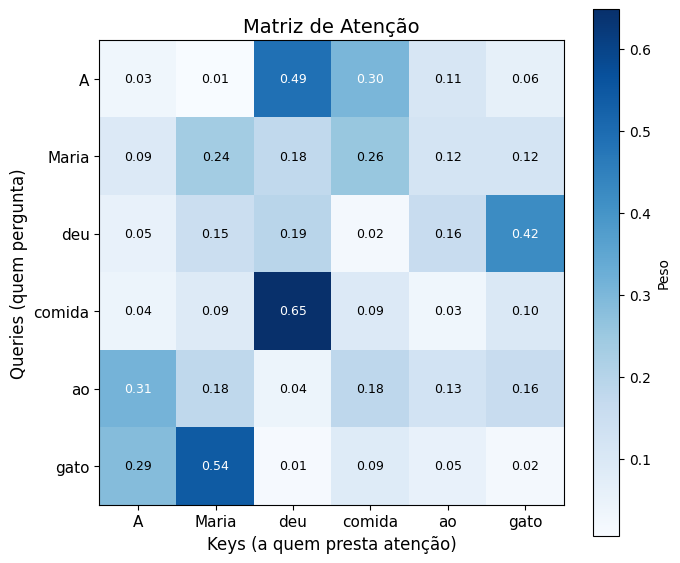


Pesos de atenção de 'gato' para cada token:
  A        → 0.286 ███████████
  Maria    → 0.541 █████████████████████
  deu      → 0.013 
  comida   → 0.085 ███
  ao       → 0.054 ██
  gato     → 0.021 


In [12]:
# ============================================================
# Exemplo: atenção na frase "A Maria deu comida ao gato"
# ============================================================

tokens_frase = ["A", "Maria", "deu", "comida", "ao", "gato"]
seq_len = len(tokens_frase)
d_k = 8  # dimensão pequena para facilitar visualização

# Simular Q, K, V (em produção, estes vêm de X @ W^Q, X @ W^K, X @ W^V)
torch.manual_seed(42)
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

# Calcular atenção
output, weights = scaled_dot_product_attention(Q, K, V)

print(f"Shape Q, K, V: {Q.shape}")
print(f"Shape output:  {output.shape}")
print(f"Shape weights: {weights.shape}")

# Visualizar a matriz de atenção
plt.figure(figsize=(7, 6))
plt.imshow(weights[0].detach().numpy(), cmap='Blues')
plt.xticks(range(seq_len), tokens_frase, fontsize=11)
plt.yticks(range(seq_len), tokens_frase, fontsize=11)
plt.xlabel('Keys (a quem presta atenção)', fontsize=12)
plt.ylabel('Queries (quem pergunta)', fontsize=12)
plt.title('Matriz de Atenção', fontsize=14)
plt.colorbar(label='Peso')

# Anotar valores
for i in range(seq_len):
    for j in range(seq_len):
        val = weights[0, i, j].item()
        color = 'white' if val > 0.3 else 'black'
        plt.text(j, i, f"{val:.2f}", ha='center', va='center',
                 fontsize=9, color=color)

plt.tight_layout()
plt.show()

# Ver especificamente a atenção de "gato" (último token)
print("\nPesos de atenção de 'gato' para cada token:")
for tok, w in zip(tokens_frase, weights[0, -1].tolist()):
    bar = '█' * int(w * 40)
    print(f"  {tok:8s} → {w:.3f} {bar}")

---
## 5. Self-Attention — Q, K, V da mesma sequência

Na **Self-Attention**, os vectores Q, K e V são todos gerados a partir da **mesma** sequência de entrada:

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

As matrizes $W^Q$, $W^K$, $W^V$ são **aprendidas** durante o treino e **partilhadas** por todos os tokens.

**`nn.Linear(in_features, out_features, bias)`:**

| Parâmetro | Tipo | Descrição |
|-----------|------|-----------|
| `in_features` | `int` | Dimensão de entrada (d_model) |
| `out_features` | `int` | Dimensão de saída (d_k) |
| `bias` | `bool` | Se incluir bias (default: `True`) |

In [13]:
class SelfAttention(nn.Module):
    """
    Self-Attention: uma única cabeça de atenção.

    Parâmetros do construtor
    ------------------------
    d_model : int
        Dimensão do embedding de entrada.
    d_k : int
        Dimensão das projeções Q, K, V.
    """
    def __init__(self, d_model, d_k):
        super().__init__()
        # Matrizes de projeção W^Q, W^K, W^V (aprendidas no treino)
        self.W_Q = nn.Linear(d_model, d_k, bias=False)  # X → Q
        self.W_K = nn.Linear(d_model, d_k, bias=False)  # X → K
        self.W_V = nn.Linear(d_model, d_k, bias=False)  # X → V

    def forward(self, X, mask=None):
        """
        Parâmetros
        ----------
        X : torch.Tensor, shape (batch, seq_len, d_model)
            Embeddings de entrada.
        mask : torch.Tensor ou None
            Máscara opcional (para atenção causal).

        Retorna
        -------
        output : torch.Tensor, shape (batch, seq_len, d_k)
        weights : torch.Tensor, shape (batch, seq_len, seq_len)
        """
        Q = self.W_Q(X)  # (batch, seq_len, d_k)
        K = self.W_K(X)  # (batch, seq_len, d_k)
        V = self.W_V(X)  # (batch, seq_len, d_k)

        output, weights = scaled_dot_product_attention(Q, K, V, mask)
        return output, weights


# ============================================================
# Testar a Self-Attention
# ============================================================

d_model = 64
d_k = 16
seq_len = 6

self_attn = SelfAttention(d_model, d_k)

# Simular embeddings de entrada (batch=1, 6 tokens, 64 dims)
torch.manual_seed(42)
X = torch.randn(1, seq_len, d_model)

output, weights = self_attn(X)

print(f"Input X:  {X.shape}")
print(f"Output:   {output.shape}")
print(f"Weights:  {weights.shape}")
print(f"\nSoma dos pesos por linha (deve ser ~1.0):")
print(f"  {weights[0].sum(dim=-1).detach().numpy().round(4)}")

Input X:  torch.Size([1, 6, 64])
Output:   torch.Size([1, 6, 16])
Weights:  torch.Size([1, 6, 6])

Soma dos pesos por linha (deve ser ~1.0):
  [1. 1. 1. 1. 1. 1.]


---
## 6. Multi-Head Attention

Uma única cabeça de atenção capta apenas **um tipo de relação**. O Multi-Head Attention corre $h$ cabeças em **paralelo**, cada uma com as suas próprias matrizes $W^Q_i$, $W^K_i$, $W^V_i$.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) \cdot W^O$$

Onde: $\text{head}_i = \text{Attention}(XW^Q_i, XW^K_i, XW^V_i)$

**No BERT-base:** $h = 12$ cabeças, $d_k = 64$, $d_{\text{model}} = 768$

In [14]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention.

    Parâmetros do construtor
    ------------------------
    d_model : int
        Dimensão do embedding (ex: 768 no BERT-base).
    num_heads : int
        Número de cabeças de atenção (ex: 12 no BERT-base).

    Nota: d_model deve ser divisível por num_heads.
          Cada cabeça terá dimensão d_k = d_model / num_heads.
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model deve ser divisível por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # dimensão por cabeça

        # Projeções lineares para Q, K, V (todas as cabeças juntas)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)

        # Projeção de saída W^O (combina as h cabeças)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X, mask=None):
        """
        Parâmetros
        ----------
        X : torch.Tensor, shape (batch, seq_len, d_model)
        mask : torch.Tensor ou None

        Retorna
        -------
        output : torch.Tensor, shape (batch, seq_len, d_model)
        weights : torch.Tensor, shape (batch, num_heads, seq_len, seq_len)
        """
        batch_size, seq_len, _ = X.shape

        # 1) Projetar Q, K, V
        Q = self.W_Q(X)  # (batch, seq_len, d_model)
        K = self.W_K(X)
        V = self.W_V(X)

        # 2) Separar em h cabeças: (batch, seq_len, d_model) → (batch, h, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 3) Aplicar atenção a cada cabeça (em paralelo graças ao broadcasting)
        attn_output, weights = scaled_dot_product_attention(Q, K, V, mask)
        # attn_output: (batch, h, seq_len, d_k)

        # 4) Concatenar as cabeças: (batch, h, seq_len, d_k) → (batch, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, self.d_model)

        # 5) Projeção final W^O
        output = self.W_O(attn_output)

        return output, weights


# ============================================================
# Testar Multi-Head Attention
# ============================================================

d_model = 64
num_heads = 4  # 4 cabeças, cada uma com d_k = 64/4 = 16
seq_len = 6

mha = MultiHeadAttention(d_model, num_heads)

torch.manual_seed(42)
X = torch.randn(1, seq_len, d_model)

output, weights = mha(X)

print(f"Input:   {X.shape}")
print(f"Output:  {output.shape}")
print(f"Weights: {weights.shape}  (batch, heads, seq, seq)")

Input:   torch.Size([1, 6, 64])
Output:  torch.Size([1, 6, 64])
Weights: torch.Size([1, 4, 6, 6])  (batch, heads, seq, seq)


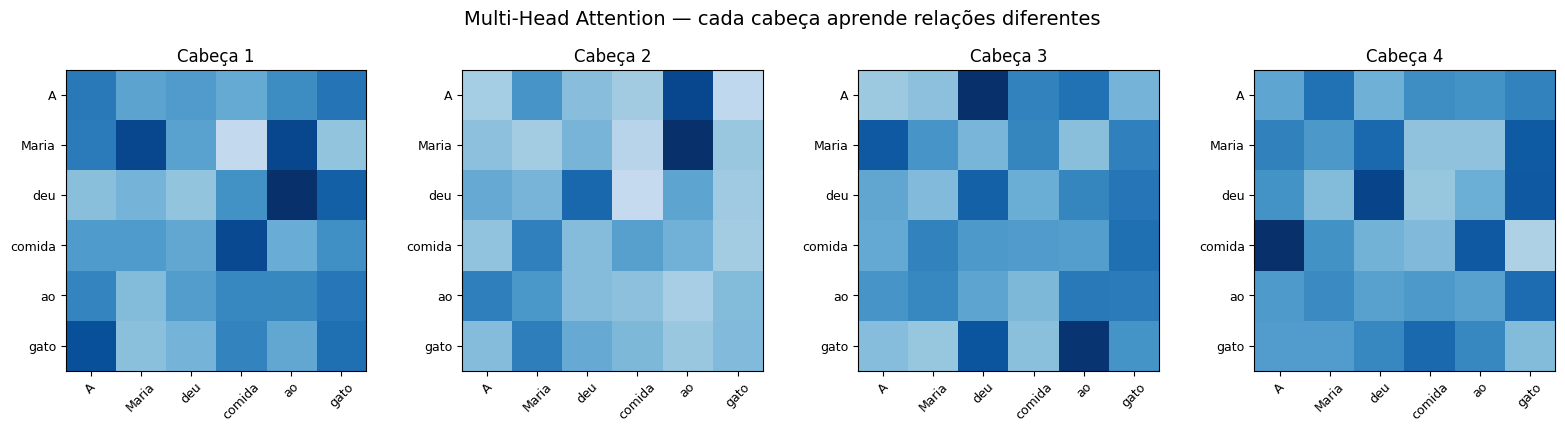

In [15]:
# ============================================================
# Visualizar as diferentes cabeças de atenção
# ============================================================

tokens_frase = ["A", "Maria", "deu", "comida", "ao", "gato"]

fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
fig.suptitle('Multi-Head Attention — cada cabeça aprende relações diferentes',
             fontsize=14, y=1.02)

for h in range(num_heads):
    ax = axes[h]
    w = weights[0, h].detach().numpy()
    ax.imshow(w, cmap='Blues', vmin=0, vmax=w.max())
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens_frase, fontsize=9, rotation=45)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(tokens_frase, fontsize=9)
    ax.set_title(f'Cabeça {h+1}', fontsize=12)

plt.tight_layout()
plt.show()

---
## 7. Bloco Transformer Completo

Um bloco Transformer combina:
1. **Multi-Head Self-Attention**
2. **Add & Norm** (conexão residual + Layer Normalization)
3. **Feed-Forward Network** (2 camadas densas com activação ReLU/GELU)
4. **Add & Norm**

Conexão residual: $\text{out} = \text{LayerNorm}(x + \text{Sublayer}(x))$

**`nn.LayerNorm(normalized_shape)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `normalized_shape` | Dimensão sobre a qual normalizar (tipicamente `d_model`) |

In [16]:
class FeedForward(nn.Module):
    """
    Feed-Forward Network do Transformer.
    Duas camadas lineares com activação GELU no meio.

    Parâmetros
    ----------
    d_model : int
        Dimensão de entrada e saída.
    d_ff : int
        Dimensão da camada intermédia (tipicamente 4 × d_model).
    dropout : float
        Taxa de dropout.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)     # expansão
        self.linear2 = nn.Linear(d_ff, d_model)     # redução
        self.dropout = nn.Dropout(dropout)
        self.gelu = nn.GELU()

    def forward(self, x):
        return self.linear2(self.dropout(self.gelu(self.linear1(x))))


class TransformerBlock(nn.Module):
    """
    Um bloco completo do Transformer (Encoder).

    Parâmetros
    ----------
    d_model : int
        Dimensão do modelo.
    num_heads : int
        Número de cabeças de atenção.
    d_ff : int
        Dimensão da FFN intermédia.
    dropout : float
        Taxa de dropout.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # Sub-camada 1: Multi-Head Attention
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)

        # Sub-camada 2: Feed-Forward Network
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Parâmetros
        ----------
        x : torch.Tensor, shape (batch, seq_len, d_model)
        mask : torch.Tensor ou None

        Retorna
        -------
        output : torch.Tensor, shape (batch, seq_len, d_model)
        weights : torch.Tensor, shape (batch, num_heads, seq_len, seq_len)
        """
        # Sub-camada 1: Attention + Residual + LayerNorm
        attn_out, weights = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_out))  # Add & Norm

        # Sub-camada 2: FFN + Residual + LayerNorm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))    # Add & Norm

        return x, weights


# ============================================================
# Testar um bloco Transformer
# ============================================================

d_model = 64
num_heads = 4
d_ff = 256  # 4 × d_model

block = TransformerBlock(d_model, num_heads, d_ff)

torch.manual_seed(42)
X = torch.randn(1, 6, d_model)  # 6 tokens

output, weights = block(X)

print(f"Input:  {X.shape}")
print(f"Output: {output.shape}  (mesma dimensão!)")

# Contar parâmetros
n_params = sum(p.numel() for p in block.parameters())
print(f"\nParâmetros do bloco: {n_params:,}")
print("\n✓ O bloco Transformer mantém a dimensão — podemos empilhar N blocos!")

Input:  torch.Size([1, 6, 64])
Output: torch.Size([1, 6, 64])  (mesma dimensão!)

Parâmetros do bloco: 49,728

✓ O bloco Transformer mantém a dimensão — podemos empilhar N blocos!


In [ ]:
# ============================================================
# Empilhar N blocos (como no BERT ou GPT)
# ============================================================

N = 6  # número de blocos (BERT-base usa 12)

blocks = nn.ModuleList([
    TransformerBlock(d_model, num_heads, d_ff) for _ in range(N)
])

# Passar a entrada por todos os blocos sequencialmente
x = X
all_weights = []
for i, block in enumerate(blocks):
    x, w = block(x)
    all_weights.append(w)

print(f"Input:  {X.shape}")
print(f"Output (após {N} blocos): {x.shape}")

total_params = sum(p.numel() for p in blocks.parameters())
print(f"\nParâmetros totais ({N} blocos): {total_params:,}")
print(f"Para comparação, BERT-base tem ~110,000,000 parâmetros")

---
## 8. BERT — Modelo Pré-treinado

Agora vamos usar um modelo BERT **real** pré-treinado pela Google.

### 8.1 Carregar o BERT e explorar a sua estrutura

**`AutoModel.from_pretrained(model_name)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `model_name` | Nome do modelo no HuggingFace Hub |

Modelos disponíveis:
- `"bert-base-uncased"` — BERT inglês (12 camadas, 110M params)
- `"neuralmind/bert-base-portuguese-cased"` — BERT português
- `"distilbert-base-uncased"` — Versão leve (6 camadas, 66M params)

In [17]:
from transformers import AutoModel

# Carregar o modelo BERT pré-treinado
bert_model = AutoModel.from_pretrained("bert-base-uncased", attn_implementation="eager")

# Ver a arquitectura
print("Arquitectura do BERT:")
print(f"  Camadas (blocos): {bert_model.config.num_hidden_layers}")
print(f"  Cabeças atenção:  {bert_model.config.num_attention_heads}")
print(f"  d_model:          {bert_model.config.hidden_size}")
print(f"  d_ff:             {bert_model.config.intermediate_size}")
print(f"  Vocabulário:      {bert_model.config.vocab_size}")
print(f"  Max sequência:    {bert_model.config.max_position_embeddings}")

# Contar parâmetros
n_params = sum(p.numel() for p in bert_model.parameters())
print(f"\n  Total parâmetros: {n_params:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Arquitectura do BERT:
  Camadas (blocos): 12
  Cabeças atenção:  12
  d_model:          768
  d_ff:             3072
  Vocabulário:      30522
  Max sequência:    512

  Total parâmetros: 109,482,240


### 8.2 Gerar embeddings contextuais com BERT

Vamos ver como a mesma palavra "banco" recebe embeddings **diferentes** conforme o contexto.

In [18]:
# ============================================================
# Embeddings contextuais — a mesma palavra, vectores diferentes
# ============================================================

frase1 = "I went to the bank to withdraw money"
frase2 = "I sat on the bank of the river"

# Tokenizar
enc1 = tokenizer_bert(frase1, return_tensors="pt")
enc2 = tokenizer_bert(frase2, return_tensors="pt")

# Passar pelo BERT (sem calcular gradientes)
bert_model.eval()
with torch.no_grad():
    out1 = bert_model(**enc1)
    out2 = bert_model(**enc2)

# Encontrar a posição de "bank" em cada frase
tokens1 = tokenizer_bert.convert_ids_to_tokens(enc1['input_ids'][0])
tokens2 = tokenizer_bert.convert_ids_to_tokens(enc2['input_ids'][0])

pos_bank1 = tokens1.index('bank')
pos_bank2 = tokens2.index('bank')

# Extrair o embedding de "bank" em cada contexto
emb_bank1 = out1.last_hidden_state[0, pos_bank1, :]
emb_bank2 = out2.last_hidden_state[0, pos_bank2, :]

# Calcular similaridade cosseno
cos_sim = F.cosine_similarity(emb_bank1.unsqueeze(0), emb_bank2.unsqueeze(0))

print(f"Frase 1: '{frase1}'")
print(f"  Tokens: {tokens1}")
print(f"  'bank' na posição {pos_bank1}")

print(f"\nFrase 2: '{frase2}'")
print(f"  Tokens: {tokens2}")
print(f"  'bank' na posição {pos_bank2}")

print(f"\nShape do embedding: {emb_bank1.shape}  (768 dimensões)")
print(f"Similaridade cosseno entre os dois 'bank': {cos_sim.item():.4f}")
print(f"\n→ Se fosse Word2Vec (embedding fixo), a similaridade seria 1.0")
print(f"→ Com BERT (contextual), são vectores DIFERENTES: {cos_sim.item():.4f}")

Frase 1: 'I went to the bank to withdraw money'
  Tokens: ['[CLS]', 'i', 'went', 'to', 'the', 'bank', 'to', 'withdraw', 'money', '[SEP]']
  'bank' na posição 5

Frase 2: 'I sat on the bank of the river'
  Tokens: ['[CLS]', 'i', 'sat', 'on', 'the', 'bank', 'of', 'the', 'river', '[SEP]']
  'bank' na posição 5

Shape do embedding: torch.Size([768])  (768 dimensões)
Similaridade cosseno entre os dois 'bank': 0.4758

→ Se fosse Word2Vec (embedding fixo), a similaridade seria 1.0
→ Com BERT (contextual), são vectores DIFERENTES: 0.4758


### 8.3 Visualizar a atenção do BERT

O BERT devolve os pesos de atenção de cada cabeça e cada camada. Vamos inspecioná-los.

Interpetação dos resultados:

Cabeça 1 — quase todos os tokens prestam atenção fortemente ao token [CLS] (primeira coluna toda escura). Isso é comum no BERT, já que o [CLS] funciona como um vetor resumo da frase inteira.

Cabeça 2 — a atenção está concentrada em "tired" e [SEP]. Parece captar o final/conclusão da frase.

Cabeça 3 — mostra atenção mais distribuída, com foco em tokens como "was" e "tired". Pode estar captando relações predicativas.

Cabeça 4 — padrão mais difuso, com atenção espalhada por vários tokens. Pode captar relações mais amplas ou contexto geral.

Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '[SEP]']
Número de camadas: 12
Shape por camada: torch.Size([1, 12, 12, 12])


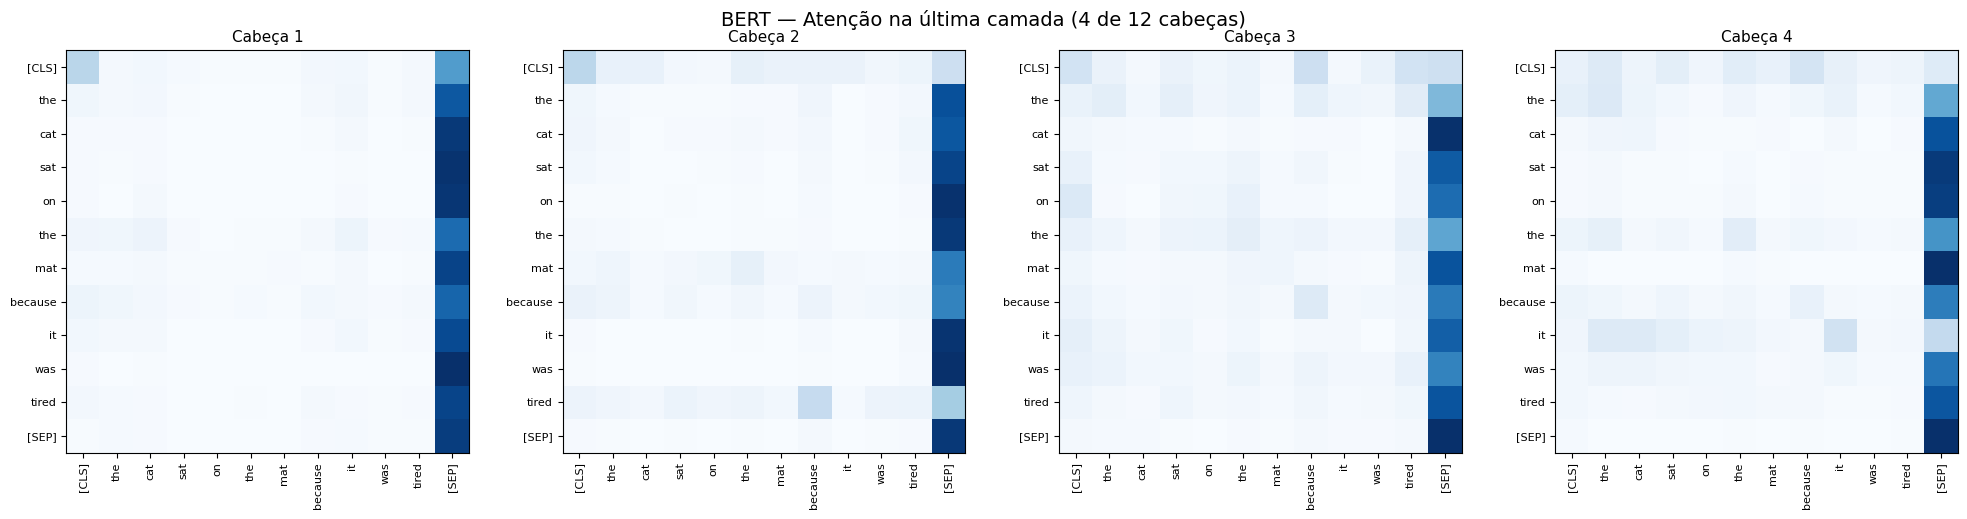

In [19]:
# ============================================================
# Extrair e visualizar atenção do BERT real
# ============================================================

frase = "The cat sat on the mat because it was tired"
enc = tokenizer_bert(frase, return_tensors="pt")

with torch.no_grad():
    out = bert_model(**enc, output_attentions=True)  # pedir pesos de atenção

# out.attentions é uma tupla com 12 camadas
# cada camada tem shape (batch, num_heads, seq_len, seq_len)
tokens = tokenizer_bert.convert_ids_to_tokens(enc['input_ids'][0])

print(f"Tokens: {tokens}")
print(f"Número de camadas: {len(out.attentions)}")
print(f"Shape por camada: {out.attentions[0].shape}")

# Visualizar 4 cabeças da última camada
layer = -1  # última camada
attn = out.attentions[layer][0]  # (num_heads, seq_len, seq_len)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'BERT — Atenção na última camada (4 de 12 cabeças)', fontsize=14)

for h in range(4):
    ax = axes[h]
    ax.imshow(attn[h].numpy(), cmap='Blues')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f'Cabeça {h+1}', fontsize=11)

plt.tight_layout()
plt.show()

### 8.4 MLM — Masked Language Modeling

O BERT foi treinado para prever tokens mascarados (`[MASK]`). Vamos testar usando o `pipeline` do HuggingFace.

**`pipeline(task, model=None)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `task` | Tarefa a realizar: `"fill-mask"`, `"sentiment-analysis"`, `"text-generation"`, etc. |
| `model` | Nome do modelo (opcional — usa default se omitido) |

In [20]:
from transformers import pipeline

# Pipeline de Masked Language Modeling
mlm = pipeline("fill-mask", model="bert-base-uncased")

# Testar com [MASK]
resultado = mlm("The cat [MASK] on the mat.")

print("Frase: 'The cat [MASK] on the mat.'\n")
print("Top 5 previsões do BERT:")
for r in resultado:
    print(f"  {r['token_str']:10s}  (score: {r['score']:.4f})")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frase: 'The cat [MASK] on the mat.'

Top 5 previsões do BERT:
  sat         (score: 0.1680)
  lay         (score: 0.0828)
  was         (score: 0.0623)
  landed      (score: 0.0533)
  collapsed   (score: 0.0499)


---
## 9. GPT — Geração de Texto

O GPT é um modelo **decoder-only** com **máscara causal** — cada token só vê os anteriores.

### 9.1 Demonstrar a máscara causal

A máscara causal é uma matriz triangular inferior que impede tokens de ver o futuro.

Máscara causal (1 = pode ver, 0 = bloqueado):
[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


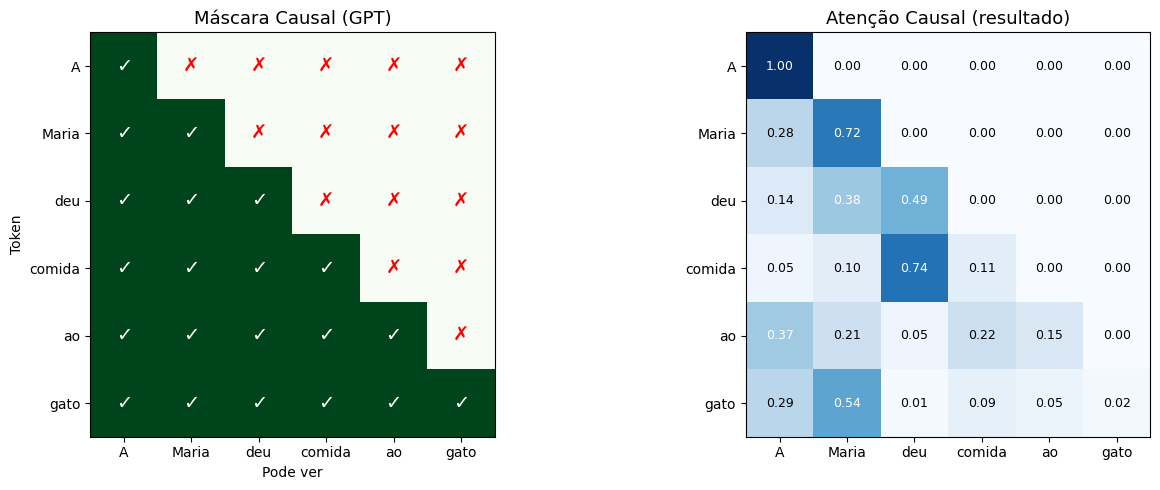


→ Cada token só presta atenção a si mesmo e aos anteriores!


In [21]:
# ============================================================
# Visualizar a máscara causal
# ============================================================

seq_len = 6
tokens_frase = ["A", "Maria", "deu", "comida", "ao", "gato"]

# Máscara causal: triangular inferior
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

print("Máscara causal (1 = pode ver, 0 = bloqueado):")
print(causal_mask.int().numpy())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Máscara
axes[0].imshow(causal_mask.numpy(), cmap='Greens')
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels(tokens_frase, fontsize=10)
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(tokens_frase, fontsize=10)
axes[0].set_title('Máscara Causal (GPT)', fontsize=13)
axes[0].set_xlabel('Pode ver')
axes[0].set_ylabel('Token')
for i in range(seq_len):
    for j in range(seq_len):
        val = '✓' if causal_mask[i, j] else '✗'
        color = 'white' if causal_mask[i, j] else 'red'
        axes[0].text(j, i, val, ha='center', va='center', fontsize=14, color=color)

# Atenção com máscara causal
torch.manual_seed(42)
Q = torch.randn(1, seq_len, 8)
K = torch.randn(1, seq_len, 8)
V = torch.randn(1, seq_len, 8)

_, weights_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask.unsqueeze(0))

axes[1].imshow(weights_causal[0].detach().numpy(), cmap='Blues')
axes[1].set_xticks(range(seq_len))
axes[1].set_xticklabels(tokens_frase, fontsize=10)
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels(tokens_frase, fontsize=10)
axes[1].set_title('Atenção Causal (resultado)', fontsize=13)
for i in range(seq_len):
    for j in range(seq_len):
        val = weights_causal[0, i, j].item()
        color = 'white' if val > 0.3 else 'black'
        axes[1].text(j, i, f"{val:.2f}", ha='center', va='center',
                     fontsize=9, color=color)

plt.tight_layout()
plt.show()

print("\n→ Cada token só presta atenção a si mesmo e aos anteriores!")

### 9.2 Gerar texto com GPT-2

**`pipeline("text-generation", model=..., ...)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `max_new_tokens` | Número máximo de tokens a gerar |
| `temperature` | Controla criatividade: 0.1 = conservador, 1.5 = criativo |
| `top_k` | Amostra dos k tokens mais prováveis |
| `do_sample` | Se `True`, usa amostragem; se `False`, usa greedy |
| `num_return_sequences` | Quantas sequências diferentes gerar |

In [22]:
# ============================================================
# Geração de texto com GPT-2
# ============================================================

generator = pipeline(
    "text-generation",
    model="gpt2"
)

prompt = "The transformer architecture has revolutionized"

print(f"Prompt: '{prompt}'\n")
print("=" * 60)

# Geração greedy (determinística)
result = generator(
    prompt,
    max_new_tokens=50,    # gerar até 50 tokens novos
    do_sample=False,      # greedy — sempre o mais provável
    num_return_sequences=1
)
print("\n[Greedy]:")
print(result[0]['generated_text'])

# Geração com sampling e temperature
print("\n" + "=" * 60)
result = generator(
    prompt,
    max_new_tokens=50,
    do_sample=True,       # activar amostragem
    temperature=0.8,      # criatividade moderada
    top_k=50,             # dos 50 mais prováveis
    num_return_sequences=2
)
for i, r in enumerate(result):
    print(f"\n[Sampling {i+1}]:")
    print(r['generated_text'])

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'num_return_sequences', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: 'The transformer architecture has revolutionized'



Passing `generation_config` together with generation-related arguments=({'do_sample', 'num_return_sequences', 'temperature', 'top_k', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[Greedy]:
The transformer architecture has revolutionized the way we use electricity. It's a great way to get rid of the need for expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive, expensive,


[Sampling 1]:
The transformer architecture has revolutionized the design and design of many new products, to the point where we can make one of the best products on the market or even out of a product."

When it comes to the power supply, the company is also using its latest technology to

[Sampling 2]:
The transformer architecture has revolutionized the way we have used this transformer. The high voltage current can be controlled by an external amplifier via the input amplifier. The low voltage is controlled by the output amplifier via the output transformer. In this way you are able to control the amount of current


---
## 10. Fine-tuning de BERT para Análise de Sentimento

Agora vamos aplicar o que aprendemos: pegar no BERT pré-treinado e **afiná-lo** para classificar textos como positivos ou negativos.

### 10.1 Carregar o dataset

Usamos o dataset **IMDb** (críticas de filmes) do HuggingFace.

**`load_dataset(name, split=...)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `name` | Nome do dataset no HuggingFace Hub |
| `split` | Partição: `"train"`, `"test"`, ou `"train[:1000]"` para subconjunto |

In [24]:
from datasets import load_dataset

# Carregar apenas um subconjunto (para ser rápido)
dataset = load_dataset("imdb", split={
    "train": "train[:1000]",  # 1000 exemplos de treino
    "test": "test[:200]"      # 200 exemplos de teste
})

print(f"Treino: {len(dataset['train'])} exemplos")
print(f"Teste:  {len(dataset['test'])} exemplos")
print(f"\nColunas: {dataset['train'].column_names}")
print(f"Labels:  0 = negativo, 1 = positivo")

# Ver um exemplo
exemplo = dataset['train'][0]
print(f"\n--- Exemplo ---")
print(f"Texto:  {exemplo['text'][:200]}...")
print(f"Label:  {exemplo['label']} ({'positivo' if exemplo['label'] else 'negativo'})")

README.md: 0.00B [00:00, ?B/s]

c:\Source\Repos\obimelo\Curso-MachineLearning-FCUP\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jamelo\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Treino: 1000 exemplos
Teste:  200 exemplos

Colunas: ['text', 'label']
Labels:  0 = negativo, 1 = positivo

--- Exemplo ---
Texto:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Label:  0 (negativo)


### 10.2 Tokenizar o dataset

Precisamos converter todos os textos em IDs numéricos antes de os passar ao BERT.

**`dataset.map(function, batched=True)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `function` | Função de transformação a aplicar |
| `batched` | Se `True`, processa em batches (mais rápido) |

In [25]:
# Usar o tokenizer do BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    """
    Tokeniza um batch de textos.

    Parâmetros
    ----------
    examples : dict
        Batch do dataset com chave 'text'.

    Retorna
    -------
    dict com input_ids, attention_mask
    """
    return tokenizer(
        examples["text"],
        padding="max_length",    # pad até max_length
        truncation=True,         # cortar se exceder
        max_length=256           # comprimento fixo
    )

# Aplicar tokenização a todo o dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Definir formato PyTorch
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("✓ Dataset tokenizado!")
print(f"Colunas: {tokenized_dataset['train'].column_names}")
print(f"Shape input_ids: {tokenized_dataset['train'][0]['input_ids'].shape}")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

✓ Dataset tokenizado!
Colunas: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
Shape input_ids: torch.Size([256])


### 10.3 Carregar BERT para classificação

**`AutoModelForSequenceClassification.from_pretrained(model, num_labels=...)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `model` | Nome do modelo pré-treinado |
| `num_labels` | Número de classes de saída (2 para sentimento) |

Isto adiciona automaticamente uma **camada de classificação** em cima do BERT (o passo 4 do slide "Afinar o BERT").

In [26]:
from transformers import AutoModelForSequenceClassification

# Carregar BERT com cabeça de classificação
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2            # 2 classes: positivo / negativo
)

# Mover para GPU se disponível
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parâmetros totais:    {n_params:,}")
print(f"Parâmetros treináveis: {n_trainable:,}")
print(f"\n→ O BERT pré-treinado + camada de classificação (768 → 2)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parâmetros totais:    109,483,778
Parâmetros treináveis: 109,483,778

→ O BERT pré-treinado + camada de classificação (768 → 2)


### 10.4 Configurar o treino com `Trainer`

O HuggingFace `Trainer` abstrai o loop de treino completo.

**`TrainingArguments(...)`** — hiperparâmetros do treino:

| Parâmetro | Descrição | Valor típico |
|-----------|-----------|------|
| `output_dir` | Pasta para guardar checkpoints | `"./resultados"` |
| `num_train_epochs` | Número de épocas | 3 |
| `per_device_train_batch_size` | Batch size por GPU | 16 |
| `learning_rate` | Taxa de aprendizagem | 2e-5 |
| `eval_strategy` | Quando avaliar: `"epoch"`, `"steps"` | `"epoch"` |
| `save_strategy` | Quando guardar checkpoints | `"epoch"` |
| `load_best_model_at_end` | Carregar o melhor modelo no final | `True` |
| `weight_decay` | Regularização L2 | 0.01 |
| `warmup_steps` | Passos de warmup para o learning rate | 100 |

**`Trainer(...)`:**

| Parâmetro | Descrição |
|-----------|-----------|
| `model` | Modelo a treinar |
| `args` | `TrainingArguments` |
| `train_dataset` | Dataset de treino |
| `eval_dataset` | Dataset de avaliação |
| `compute_metrics` | Função para calcular métricas |

In [27]:
from transformers import TrainingArguments, Trainer
import numpy as np

def compute_metrics(eval_pred):
    """
    Calcula accuracy a partir das previsões.

    Parâmetros
    ----------
    eval_pred : EvalPrediction
        Contém .predictions (logits) e .label_ids (labels verdadeiras).
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}


# Configurar hiperparâmetros
training_args = TrainingArguments(
    output_dir="./resultados",
    num_train_epochs=3,                  # 3 épocas
    per_device_train_batch_size=16,      # batch size
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                  # LR baixo (fine-tuning)
    weight_decay=0.01,                   # regularização
    eval_strategy="epoch",               # avaliar no fim de cada época
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,                    # log a cada 50 steps
    report_to="none",                    # desligar W&B/MLflow
)

# Criar o Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
)

print("✓ Trainer configurado!")
print(f"  Épocas: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=1.1.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=1.1.0'`

### 10.5 Treinar!

O `trainer.train()` executa o loop completo: forward pass → loss → backpropagation → update dos pesos.

In [ ]:
# ============================================================
# Treinar o modelo (fine-tuning)
# ============================================================

trainer.train()

In [ ]:
# ============================================================
# Avaliar no conjunto de teste
# ============================================================

results = trainer.evaluate()

print("\n" + "=" * 40)
print("Resultados no conjunto de teste:")
print("=" * 40)
print(f"  Loss:     {results['eval_loss']:.4f}")
print(f"  Accuracy: {results['eval_accuracy']:.4f}  ({results['eval_accuracy']*100:.1f}%)")

### 10.6 Testar com frases novas

Agora que o modelo está afinado, vamos testá-lo com frases que ele nunca viu.

In [ ]:
# ============================================================
# Testar o modelo afinado com frases novas
# ============================================================

frases_teste = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Terrible film. Waste of time and money.",
    "The acting was decent but the plot was confusing.",
    "One of the best movies I have ever seen!",
    "I fell asleep halfway through. So boring.",
]

model.eval()

print("Previsões do modelo afinado:\n")
for frase in frases_teste:
    inputs = tokenizer(frase, return_tensors="pt", truncation=True,
                       max_length=256, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs, dim=-1).item()
    confidence = probs[0, pred].item()
    label = "POSITIVO ✓" if pred == 1 else "NEGATIVO ✗"

    print(f"  [{label}] ({confidence:.1%}) {frase[:60]}...")

---
## Resumo

Neste notebook percorremos todos os componentes de um Transformer:

| Componente | O que fizemos |
|------------|---------------|
| **Tokenização** | Comparámos word-level vs subword (BERT vs GPT) |
| **Embeddings** | Criámos embedding layer e visualizámos embeddings contextuais |
| **Positional Encoding** | Implementámos PE com senos/cossenos e visualizámos padrões |
| **Scaled Dot-Product Attention** | Implementámos do zero, visualizámos pesos |
| **Self-Attention** | Implementámos com projeções W^Q, W^K, W^V aprendíveis |
| **Multi-Head Attention** | Implementámos h cabeças em paralelo |
| **Bloco Transformer** | Combinámos atenção + FFN + residual + LayerNorm |
| **BERT** | Explorámos embeddings contextuais e MLM |
| **GPT** | Demonstrámos máscara causal e geração de texto |
| **Fine-tuning** | Afinámos BERT para análise de sentimento |

### Para continuar a explorar:
- [HuggingFace NLP Course](https://huggingface.co/learn)
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
- Vaswani et al. (2017) — *Attention Is All You Need*
- Devlin et al. (2018) — *BERT: Pre-training of Deep Bidirectional Transformers*